# Comparación de kernels SVM (lineal, polinómico y RBF)
Notebook de práctica 

**Dataset:** `dataset_svm_3features.csv` (x1, x2, x3, y)


## 1. Importaciones y configuración
Importamos librerías que nos harán falta

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_moons, make_circles
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz, DecisionTreeRegressor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, r2_score, mean_squared_error

## 2. Carga del dataset

Asegúrate de que el Dataset es correcto y está en la ruta adecuada

In [71]:
alumnos = pd.read_csv("dataset_svm_3.csv")
alumnos.head()

,x1,x2,x3,y
0,1.956471,0.522024,3.729120,1
1,1.028349,-0.815309,0.344379,1
2,0.772477,0.487892,0.585373,0
3,-0.546762,0.550913,0.528503,0
4,0.931783,0.307020,0.692005,0


## 3. Exploración del Dataset

Estudia las características más importantes del Dataset: Estructura, tipos, entre otras

In [72]:
alumnos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      1200 non-null   float64
 1   x2      1200 non-null   float64
 2   x3      1200 non-null   float64
 3   y       1200 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 37.6 KB


In [73]:
alumnos.describe()

,x1,x2,x3,y
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,0.495628,0.245578,0.724498,0.500000
std,0.908439,0.546897,1.496208,0.500208
min,-1.517920,-1.044313,-2.523007,0.000000
25%,-0.144652,-0.189703,-0.228058,0.000000
50%,0.500767,0.241160,0.357092,0.500000
75%,1.149854,0.684919,1.332938,1.000000
max,2.503825,1.624435,6.471865,1.000000


Usando columnas: x1, x2, x3


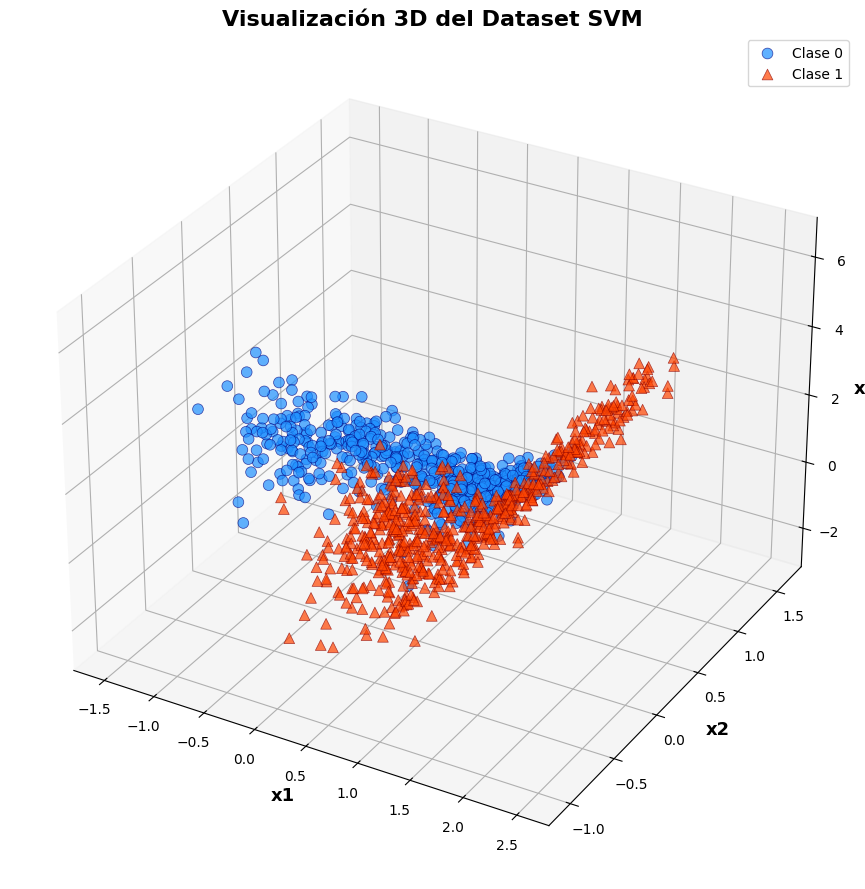

In [74]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Crear figura 3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Separar por clase
clase_0 = alumnos[alumnos['y'] == 0]
clase_1 = alumnos[alumnos['y'] == 1]

# Obtener nombres de columnas (las primeras 3 son x1, x2, x3)
col1, col2, col3 = alumnos.columns[0], alumnos.columns[1], alumnos.columns[2]

print(f"Usando columnas: {col1}, {col2}, {col3}")

# Graficar cada clase
ax.scatter(clase_0[col1], clase_0[col2], clase_0[col3], 
           c='dodgerblue', marker='o', s=60, alpha=0.7, 
           label='Clase 0', edgecolors='navy', linewidth=0.5)

ax.scatter(clase_1[col1], clase_1[col2], clase_1[col3], 
           c='orangered', marker='^', s=60, alpha=0.7, 
           label='Clase 1', edgecolors='darkred', linewidth=0.5)

# Etiquetas
ax.set_xlabel(col1, fontsize=13, fontweight='bold')
ax.set_ylabel(col2, fontsize=13, fontweight='bold')
ax.set_zlabel(col3, fontsize=13, fontweight='bold')
ax.set_title('Visualización 3D del Dataset SVM', fontsize=16, fontweight='bold')

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Preparación de datos


1) Separar `X` e `y`

2) Dividir en train/test

3) Escalar con `StandardScaler`

In [75]:

X = alumnos[["x1", "x2", "x3"]]
y = alumnos["y"]

print(X.shape)
print(y.shape)

(1200, 3)
(1200,)


In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (960, 3), Test: (240, 3)


In [77]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Entrenamiento y evaluación

Entrenamos los modelos elegidos con parámetros iniciales razonables

In [78]:
svm_lineal = SVC(kernel="linear", C=0.1, random_state=42)
svm_lineal.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [79]:
svm_rbf = SVC(kernel="rbf", C=0.1, gamma=1.0, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1.0
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [80]:
svm_poly = SVC(kernel="poly", C=5, degree=3, coef0=0.5, random_state=42)
svm_poly.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",5
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.5
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [81]:
pred_poly = svm_poly.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred_poly))
print(confusion_matrix(y_test, pred_poly))
print(classification_report(y_test, pred_poly))

Accuracy: 0.9625
[[116   4]
 [  5 115]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       120
           1       0.97      0.96      0.96       120

    accuracy                           0.96       240
   macro avg       0.96      0.96      0.96       240
weighted avg       0.96      0.96      0.96       240



### Función de evaluación
Cómo evaluamos

In [82]:
y_pred = svm_poly.predict(X_test_scaled)

y_pred_df = X_test.copy()
y_pred_df['y_pred'] = y_pred
y_pred_df['y_real'] = y_test.values

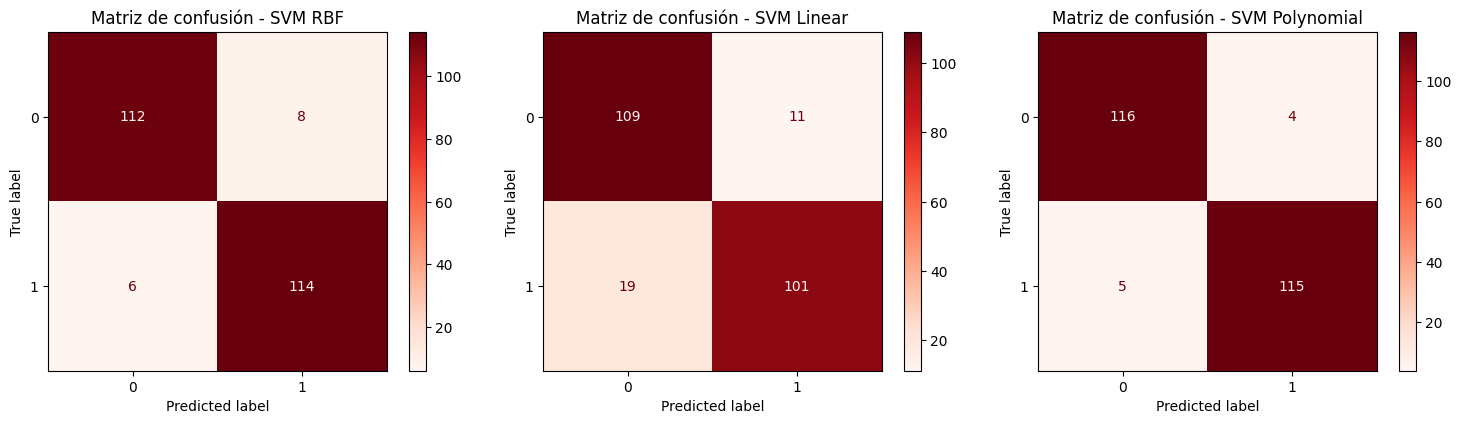

MÉTRICAS DE LOS MODELOS SVM

SVM RBF:
Accuracy: 0.9417

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       120
           1       0.93      0.95      0.94       120

    accuracy                           0.94       240
   macro avg       0.94      0.94      0.94       240
weighted avg       0.94      0.94      0.94       240

------------------------------------------------------------

SVM Linear:
Accuracy: 0.8750

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       120
           1       0.90      0.84      0.87       120

    accuracy                           0.88       240
   macro avg       0.88      0.88      0.87       240
weighted avg       0.88      0.88      0.87       240

------------------------------------------------------------

SVM Polynomial:
Accuracy: 0.9625

Classification Report:
              precision    recall

In [83]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

# Asumiendo que ya tienes entrenados los tres modelos:
# svm_rbf, svm_linear, svm_poly

# Hacer predicciones con cada modelo
y_pred_rbf = svm_rbf.predict(X_test_scaled)
y_pred_linear = svm_lineal.predict(X_test_scaled)
y_pred_poly = svm_poly.predict(X_test_scaled)

# Crear figura con 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Lista de predicciones y títulos
modelos = [
    (y_pred_rbf, "SVM RBF"),
    (y_pred_linear, "SVM Linear"),
    (y_pred_poly, "SVM Polynomial")
]

# Crear matriz de confusión para cada modelo
for idx, (y_pred, titulo) in enumerate(modelos):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Reds", ax=axes[idx])
    axes[idx].set_title(f"Matriz de confusión - {titulo}")

plt.tight_layout()
plt.show()

# Imprimir métricas para cada modelo
print("MÉTRICAS DE LOS MODELOS SVM")

for y_pred, titulo in modelos:
    print(f"\n{titulo}:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("-"*60)

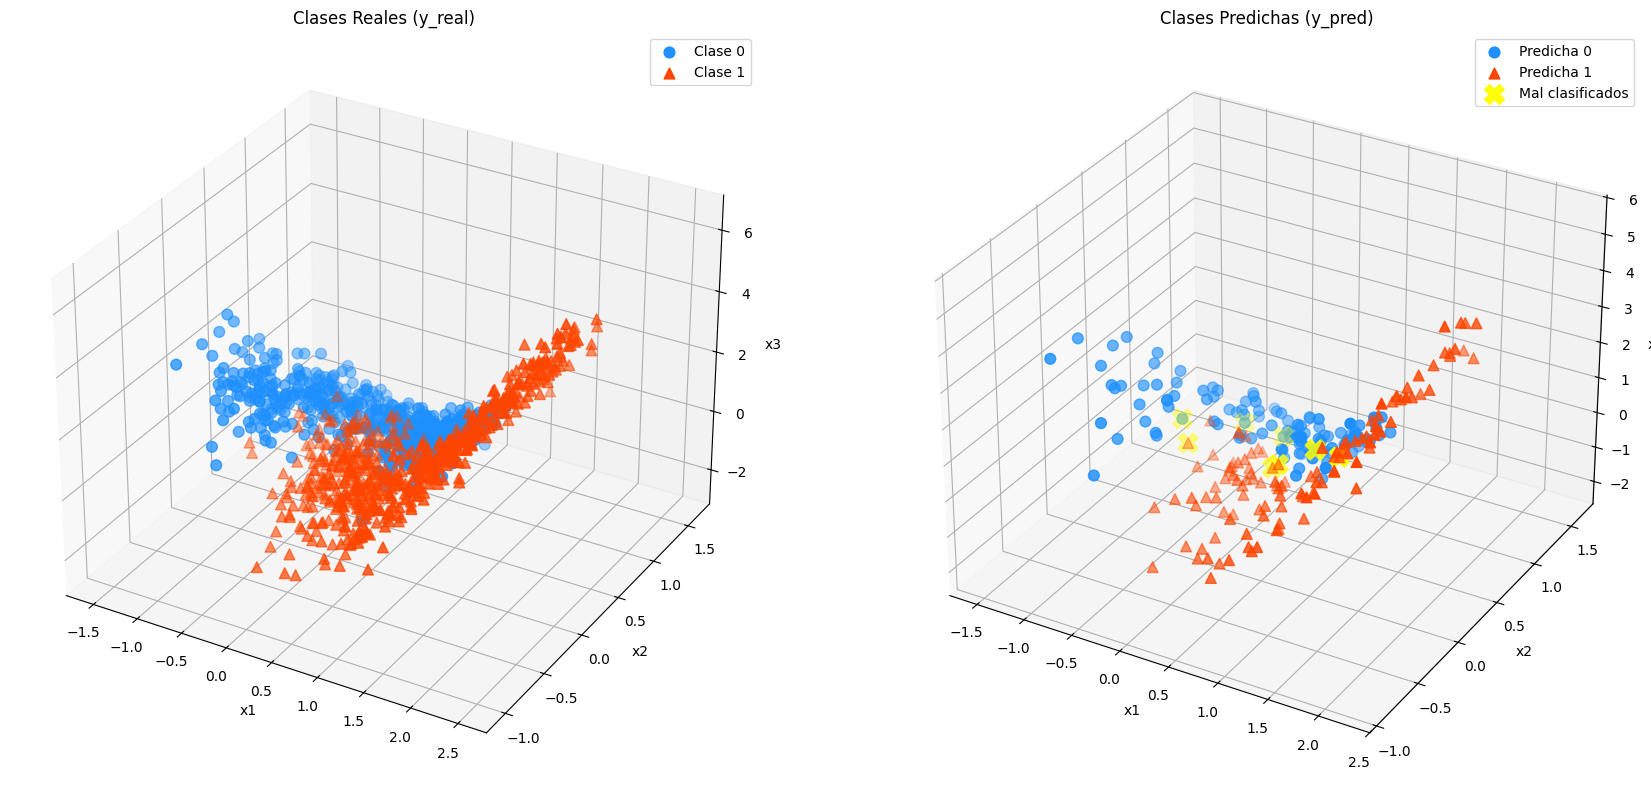

In [84]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # aunque no siempre es necesario importarlo explícitamente

col1, col2, col3 = y_pred_df.columns[0:3]

fig = plt.figure(figsize=(18, 8))

# ------------------ Gráfico 1: Clases Reales ------------------
ax1 = fig.add_subplot(121, projection='3d')
# clase_0_real = y_pred_df[y_pred_df['y_real'] == 0]
# clase_1_real = y_pred_df[y_pred_df['y_real'] == 1]

clase_0_real = alumnos[alumnos['y'] == 0]
clase_1_real = alumnos[alumnos['y'] == 1]

ax1.scatter(clase_0_real[col1], clase_0_real[col2], clase_0_real[col3],
            c='dodgerblue', marker='o', s=60, label='Clase 0')
ax1.scatter(clase_1_real[col1], clase_1_real[col2], clase_1_real[col3],
            c='orangered', marker='^', s=60, label='Clase 1')

ax1.set_xlabel(col1)
ax1.set_ylabel(col2)
ax1.set_zlabel(col3)
ax1.set_title('Clases Reales (y_real)')
ax1.legend()

# ------------------ Gráfico 2: Clases Predichas ------------------
ax2 = fig.add_subplot(122, projection='3d')
clase_0_pred = y_pred_df[y_pred_df['y_pred'] == 0]
clase_1_pred = y_pred_df[y_pred_df['y_pred'] == 1]

ax2.scatter(clase_0_pred[col1], clase_0_pred[col2], clase_0_pred[col3],
            c='dodgerblue', marker='o', s=60, label='Predicha 0')
ax2.scatter(clase_1_pred[col1], clase_1_pred[col2], clase_1_pred[col3],
            c='orangered', marker='^', s=60, label='Predicha 1')

# Resaltar errores
errores = y_pred_df[y_pred_df['y_real'] != y_pred_df['y_pred']]
ax2.scatter(errores[col1], errores[col2], errores[col3],
            c='yellow', s=200, marker='X', label='Mal clasificados')

ax2.set_xlabel(col1)
ax2.set_ylabel(col2)
ax2.set_zlabel(col3)
ax2.set_title('Clases Predichas (y_pred)')
ax2.legend()

plt.tight_layout()
plt.show()


### Evaluación detallada de los modelos elegidos

## 6. Ajuste de hiperparámetros



In [85]:

valores_C = [0.1, 1, 5, 10, 50, 100]
valores_gamma = [0.001, 0.01, 0.1, 1]
valores_degree = [2, 3, 4, 5]
valores_coef0 = [0, 0.5, 1, 2]

# Funcion que recibe como parametro el tipo de kernel para entrenar el modelo con distintos hiperparametros almacenados en listas
def mejor_eleccion(kernel):
    mejor_acc = 0
    mejor_config = None

    for C in valores_C:

        # LINEAR
        if kernel == 'linear':
            print(f"\nProbando LINEAR | C={C}")

            svm = SVC(kernel='linear', C=C, random_state=42)

            svm.fit(X_train_scaled, y_train)
            pred = svm.predict(X_test_scaled)
            acc = accuracy_score(y_test, pred)

            print(f"Accuracy: {acc:.4f}")

            if acc > mejor_acc:
                mejor_acc = acc
                mejor_config = ('linear', C)

        # RBF
        elif kernel == 'rbf':
            for gamma in valores_gamma:
                print(f"\nProbando RBF | C={C} | gamma={gamma}")

                svm = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)

                svm.fit(X_train_scaled, y_train)
                pred = svm.predict(X_test_scaled)
                acc = accuracy_score(y_test, pred)

                print(f"Accuracy: {acc:.4f}")

                if acc > mejor_acc:
                    mejor_acc = acc
                    mejor_config = ('rbf', C, gamma)

        # POLY 
        elif kernel == 'poly':
            for degree in valores_degree:
                for coef0 in valores_coef0:
                    print(f"\nProbando POLY | C={C} | degree={degree} | coef0={coef0}")

                    svm = SVC(kernel='poly', C=C, degree=degree, coef0=coef0, random_state=42)

                    svm.fit(X_train_scaled, y_train)
                    pred = svm.predict(X_test_scaled)
                    acc = accuracy_score(y_test, pred)

                    print(f"Accuracy: {acc:.4f}")

                    if acc > mejor_acc:
                        mejor_acc = acc
                        mejor_config = ('poly', C, degree, coef0)

    print(f"\nMejor Accuracy: {mejor_acc:.4f}")
    print(f"Mejor configuración: {mejor_config}")


In [87]:
mejor_eleccion("poly")


Probando POLY | C=0.1 | degree=2 | coef0=0
Accuracy: 0.7833

Probando POLY | C=0.1 | degree=2 | coef0=0.5
Accuracy: 0.9125

Probando POLY | C=0.1 | degree=2 | coef0=1
Accuracy: 0.9083

Probando POLY | C=0.1 | degree=2 | coef0=2
Accuracy: 0.9042

Probando POLY | C=0.1 | degree=3 | coef0=0
Accuracy: 0.8667

Probando POLY | C=0.1 | degree=3 | coef0=0.5
Accuracy: 0.9167

Probando POLY | C=0.1 | degree=3 | coef0=1
Accuracy: 0.9167

Probando POLY | C=0.1 | degree=3 | coef0=2
Accuracy: 0.9167

Probando POLY | C=0.1 | degree=4 | coef0=0
Accuracy: 0.7583

Probando POLY | C=0.1 | degree=4 | coef0=0.5
Accuracy: 0.9208

Probando POLY | C=0.1 | degree=4 | coef0=1
Accuracy: 0.9333

Probando POLY | C=0.1 | degree=4 | coef0=2
Accuracy: 0.9458

Probando POLY | C=0.1 | degree=5 | coef0=0
Accuracy: 0.8417

Probando POLY | C=0.1 | degree=5 | coef0=0.5
Accuracy: 0.9250

Probando POLY | C=0.1 | degree=5 | coef0=1
Accuracy: 0.9458

Probando POLY | C=0.1 | degree=5 | coef0=2
Accuracy: 0.9542

Probando POLY |

### 6.1 modelo 1: Ajuste de Hiperparámetros

### 6.2 modelo 2: Ajueste de Hiperparámetros

## 7. Comparación final
Comparación de Métricas de cada modelo

## 8. Conclusiones

Responde las siguientes cuestiones:

1) ¿Qué kernel obtiene mejor rendimiento?

- LINEAR: C(1) = 0.8667
- RBF: C(50), gamma(1) = 0.9567
- POLY: C(1), degree(4), coef0(2) = 0.9567

2) ¿Por qué el kernel lineal se comporta peor aquí?

En este caso el kerner lineal se comporta peor ya que no podemos separar con una linea recta este conjunto de datos.

3) Entre polinómico y RBF: ¿qué ventajas/inconvenientes ves (flexibilidad, riesgo de sobreajuste, facilidad de ajuste)?



4) ¿Qué hiperparámetros han sido más determinantes (`C`, `gamma`, `grado`) y por qué?

